# Movie Review Polarity: TF-IDF From Scratch and a Cross-Validated Model Comparison

## Project Overview

This project classifies 2,000 full-length movie reviews as positive or negative. It has two parts:

1. **TF-IDF from scratch.** I implement vocabulary building, term counting, and TF-IDF weighting with NumPy and SciPy. I then verify that the output matches scikit-learn's `TfidfVectorizer` to floating-point precision.
2. **Model comparison.** Multinomial Naive Bayes, logistic regression, and a linear SVM are compared with 5-fold cross-validation. The best configuration is tuned and then evaluated once on a held-out test set.

With only 1,600 training reviews, the project also uses a learning curve to check whether more data would help, and closes with an analysis of the reviews the model gets wrong.

**Tools:** Python, NumPy, SciPy, scikit-learn, NLTK (corpus access), pandas, matplotlib, seaborn.

## Objective

Show a working understanding of how text becomes a feature matrix, and choose a well-validated linear classifier for small-sample document classification.

## Dataset

| Property | Value |
|---|---|
| Name | Movie Review Polarity Dataset v2.0 (Pang & Lee, 2004) |
| Access | `nltk.corpus.movie_reviews`, downloaded automatically by the notebook |
| Size | 2,000 reviews (1,000 positive, 1,000 negative) |
| Format | Lowercased and pre-tokenized English text from IMDb review archives |

The corpus is distributed by Cornell University for research use and bundled in NLTK's data repository. Because it downloads on demand, no data files are stored in this repository.

## Setup and Imports

In [ ]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, learning_curve, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

RANDOM_SEED = 42
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_colwidth", 120)

try:
    nltk.data.find("corpora/movie_reviews")
except LookupError:
    nltk.download("movie_reviews", quiet=True)
from nltk.corpus import movie_reviews

## Data Preparation

In [ ]:
reviews = pd.DataFrame([
    {"text": movie_reviews.raw(file_id), "label": category}
    for category in movie_reviews.categories()
    for file_id in movie_reviews.fileids(category)
])
reviews["words"] = reviews["text"].str.split().str.len()

missing_or_blank = reviews["text"].str.strip().eq("").sum()
duplicates = reviews["text"].duplicated().sum()
print(f"Reviews: {len(reviews):,} | blank: {missing_or_blank} | duplicates: {duplicates}")
print(reviews["label"].value_counts().to_string())

train_df, test_df = train_test_split(
    reviews, test_size=0.2, stratify=reviews["label"], random_state=RANDOM_SEED
)
print(f"\nTrain: {len(train_df):,}  Test: {len(test_df):,}")

Reviews: 2,000 | blank: 0 | duplicates: 0
label
neg    1000
pos    1000

Train: 1,600  Test: 400


## Exploratory Analysis

These reviews are long, with a median of about 700 words. Many of them spend most of their length summarizing the plot before giving an opinion, so a classifier has to find a sentiment signal inside mostly neutral text.

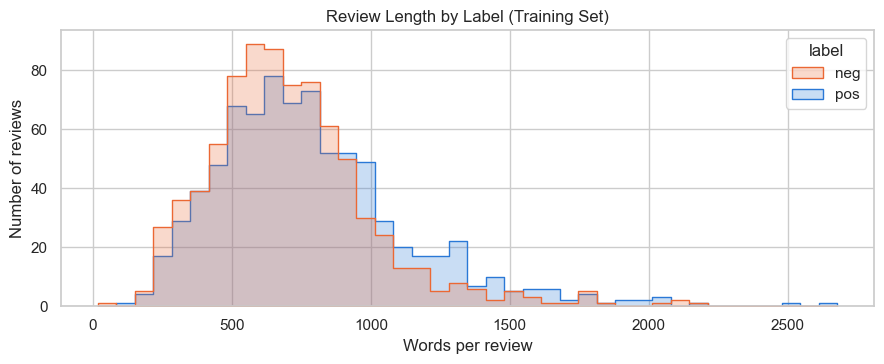

,mean,50%,min,max
label,,,,
neg,706.0,668.0,17.0,2181.0
pos,786.0,727.0,130.0,2678.0


In [ ]:
fig, ax = plt.subplots(figsize=(9, 3.8))
sns.histplot(data=train_df, x="words", hue="label", hue_order=["neg", "pos"],
             palette={"neg": "#eb6834", "pos": "#2a78d6"}, bins=40, element="step", ax=ax)
ax.set_title("Review Length by Label (Training Set)")
ax.set_xlabel("Words per review")
ax.set_ylabel("Number of reviews")
plt.tight_layout()
plt.show()

train_df.groupby("label")["words"].describe()[["mean", "50%", "min", "max"]].round(0)

## TF-IDF From Scratch

The implementation follows scikit-learn's default definitions so that the two outputs can be compared exactly:

- **Tokens**: lowercase runs of two or more word characters, using the regular expression `\b\w\w+\b`.
- **Term frequency**: the raw count of term *t* in document *d*.
- **Inverse document frequency**: `idf(t) = ln((1 + n) / (1 + df(t))) + 1`, where *n* is the number of documents and *df(t)* is the number of documents that contain *t*. The `+1` terms prevent division by zero and keep every term's weight positive.
- **Normalization**: each document vector is scaled to unit L2 length, so long reviews do not dominate.

The vocabulary and IDF values are learned from the training set only and then reused to transform the test set.

In [ ]:
TOKEN_PATTERN = re.compile(r"(?u)\b\w\w+\b")


class ScratchTfidf:
    """Minimal TF-IDF vectorizer matching scikit-learn's default settings."""

    def tokenize(self, text):
        return TOKEN_PATTERN.findall(text.lower())

    def fit(self, documents):
        document_frequency = Counter()
        for doc in documents:
            document_frequency.update(set(self.tokenize(doc)))
        # Alphabetical column order, as in scikit-learn
        self.vocabulary_ = {term: i for i, term in enumerate(sorted(document_frequency))}
        n_docs = len(documents)
        df = np.array([document_frequency[term] for term in self.vocabulary_])
        self.idf_ = np.log((1 + n_docs) / (1 + df)) + 1
        return self

    def count_matrix(self, documents):
        rows, cols, values = [], [], []
        for row, doc in enumerate(documents):
            counts = Counter(t for t in self.tokenize(doc) if t in self.vocabulary_)
            rows.extend([row] * len(counts))
            cols.extend(self.vocabulary_[t] for t in counts)
            values.extend(counts.values())
        return sparse.csr_matrix((values, (rows, cols)), shape=(len(documents), len(self.vocabulary_)), dtype=float)

    def transform(self, documents):
        weighted = self.count_matrix(documents).multiply(self.idf_).tocsr()
        row_norms = np.sqrt(weighted.multiply(weighted).sum(axis=1)).A1
        row_norms[row_norms == 0] = 1.0
        return sparse.diags(1 / row_norms) @ weighted


scratch = ScratchTfidf().fit(train_df["text"].tolist())
X_test_scratch = scratch.transform(test_df["text"].tolist())

reference = TfidfVectorizer().fit(train_df["text"])
X_test_sklearn = reference.transform(test_df["text"])

print(f"Vocabulary size (scratch / scikit-learn): {len(scratch.vocabulary_):,} / {len(reference.vocabulary_):,}")
print(f"Same vocabulary and column order: {list(scratch.vocabulary_) == list(reference.get_feature_names_out())}")
print(f"IDF values match: {np.allclose(scratch.idf_, reference.idf_)}")
print(f"Test matrices match: {np.allclose(X_test_scratch.toarray(), X_test_sklearn.toarray())}")
print(f"Largest absolute difference: {abs(X_test_scratch - X_test_sklearn).max():.2e}")

Vocabulary size (scratch / scikit-learn): 36,352 / 36,352
Same vocabulary and column order: True
IDF values match: True


Test matrices match: True
Largest absolute difference: 4.44e-16


The terms with the lowest and highest IDF show how the weighting works. Words that appear in nearly every review get the minimum weight, while rare terms get the maximum.

In [ ]:
idf_series = pd.Series(scratch.idf_, index=list(scratch.vocabulary_))
pd.DataFrame({
    "Lowest-IDF terms": idf_series.nsmallest(10).index,
    "IDF (low)": idf_series.nsmallest(10).round(3).values,
    "Example highest-IDF terms": idf_series.nlargest(10).index,
    "IDF (high)": idf_series.nlargest(10).round(3).values,
})

,Lowest-IDF terms,IDF (low),Example highest-IDF terms,IDF (high)
0,and,1.001,0009f,7.685
1,the,1.001,00s,7.685
2,to,1.001,10000,7.685
3,of,1.001,104,7.685
4,in,1.002,107,7.685
5,is,1.002,109,7.685
6,it,1.017,10b,7.685
7,that,1.018,10s,7.685
8,with,1.029,10th,7.685
9,for,1.036,111,7.685


## Model Development

### Cross-validated comparison

Each model is wrapped in a pipeline with its vectorizer, so every cross-validation fold fits its vocabulary only on that fold's training portion. This prevents leakage from the validation fold. Naive Bayes uses raw counts, which match its multinomial assumption. The linear models use TF-IDF.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
X_train, y_train = train_df["text"], train_df["label"]

candidates = {
    "Majority class": make_pipeline(CountVectorizer(), DummyClassifier(strategy="most_frequent")),
    "Naive Bayes (counts)": make_pipeline(CountVectorizer(), MultinomialNB()),
    "Logistic regression (TF-IDF)": make_pipeline(TfidfVectorizer(), LogisticRegression(max_iter=2000)),
    "Linear SVM (TF-IDF)": make_pipeline(TfidfVectorizer(), LinearSVC()),
    "Linear SVM (TF-IDF, 1-2 grams)": make_pipeline(TfidfVectorizer(ngram_range=(1, 2), min_df=2), LinearSVC()),
}

cv_results = {}
for name, pipeline in candidates.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results[name] = {"CV accuracy (mean)": scores.mean(), "CV accuracy (std)": scores.std()}

pd.DataFrame(cv_results).T.round(3)

,CV accuracy (mean),CV accuracy (std)
Majority class,0.500,0.000
Naive Bayes (counts),0.822,0.018
Logistic regression (TF-IDF),0.821,0.023
Linear SVM (TF-IDF),0.842,0.014
"Linear SVM (TF-IDF, 1-2 grams)",0.852,0.012


### Tuning the best model family

Starting from the strongest family, a small grid search tunes the regularization strength, the n-gram range, and sublinear term frequency (`1 + log(tf)`), which reduces the influence of words repeated many times in long reviews.

In [ ]:
search = GridSearchCV(
    make_pipeline(TfidfVectorizer(min_df=2), LinearSVC()),
    param_grid={
        "tfidfvectorizer__ngram_range": [(1, 1), (1, 2)],
        "tfidfvectorizer__sublinear_tf": [False, True],
        "linearsvc__C": [0.1, 0.3, 1, 3],
    },
    cv=cv, scoring="accuracy", n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print(f"Best CV accuracy: {search.best_score_:.3f}")

grid_table = pd.DataFrame(search.cv_results_)[
    ["param_tfidfvectorizer__ngram_range", "param_tfidfvectorizer__sublinear_tf", "param_linearsvc__C",
     "mean_test_score", "std_test_score"]
].rename(columns=lambda c: c.replace("param_", "").replace("tfidfvectorizer__", "").replace("linearsvc__", ""))
grid_table.sort_values("mean_test_score", ascending=False).head(6).round(3)

Best parameters: {'linearsvc__C': 3, 'tfidfvectorizer__ngram_range': (1, 2), 'tfidfvectorizer__sublinear_tf': True}
Best CV accuracy: 0.881


,ngram_range,sublinear_tf,C,mean_test_score,std_test_score
15,"(1, 2)",True,3.0,0.881,0.013
9,"(1, 1)",True,1.0,0.877,0.015
11,"(1, 2)",True,1.0,0.876,0.011
13,"(1, 1)",True,3.0,0.872,0.014
5,"(1, 1)",True,0.3,0.871,0.018
7,"(1, 2)",True,0.3,0.870,0.013


## Model Evaluation

The tuned model is evaluated once on the 400 held-out test reviews.

Test accuracy: 0.885

              precision    recall  f1-score   support

         neg      0.901     0.865     0.883       200
         pos      0.870     0.905     0.887       200

    accuracy                          0.885       400
   macro avg      0.886     0.885     0.885       400
weighted avg      0.886     0.885     0.885       400



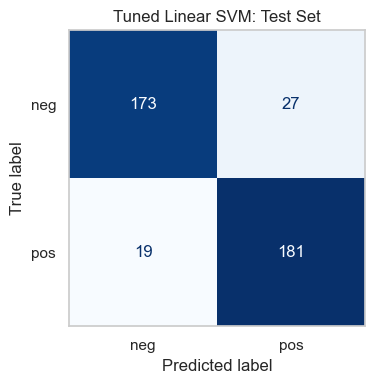

In [ ]:
final_model = search.best_estimator_
test_predictions = final_model.predict(test_df["text"])

print(f"Test accuracy: {accuracy_score(test_df['label'], test_predictions):.3f}\n")
print(classification_report(test_df["label"], test_predictions, digits=3))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(test_df["label"], test_predictions, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Tuned Linear SVM: Test Set")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.grid(False)
plt.tight_layout()
plt.show()

### Learning curve

With only 1,600 training reviews, it is worth checking whether the model is limited by data or by capacity. The curve retrains the tuned pipeline on growing subsets of the training data, using the same cross-validation folds.

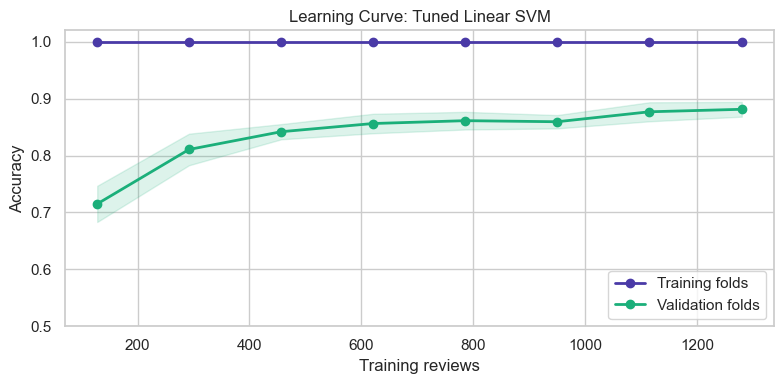

,0,1,2,3,4,5,6,7
Training reviews,128.000,292.000,457.000,621.000,786.000,950.000,1115.000,1280.000
Validation accuracy,0.715,0.811,0.842,0.856,0.861,0.859,0.877,0.881


In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_train, y_train, cv=cv, train_sizes=np.linspace(0.1, 1.0, 8),
    scoring="accuracy", n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_sizes, train_scores.mean(axis=1), marker="o", color="#4a3aa7", linewidth=2, label="Training folds")
ax.plot(train_sizes, val_scores.mean(axis=1), marker="o", color="#1baf7a", linewidth=2, label="Validation folds")
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), color="#1baf7a", alpha=0.15)
ax.set_title("Learning Curve: Tuned Linear SVM")
ax.set_xlabel("Training reviews")
ax.set_ylabel("Accuracy")
ax.set_ylim(0.5, 1.02)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

pd.DataFrame({"Training reviews": train_sizes, "Validation accuracy": val_scores.mean(axis=1).round(3)}).T

## Error Analysis

### Most influential features

In [ ]:
vectorizer, classifier = final_model[0], final_model[-1]
weights = pd.Series(classifier.coef_[0], index=vectorizer.get_feature_names_out())
pd.DataFrame({
    "Strongest negative features": weights.nsmallest(15).index,
    "Strongest positive features": weights.nlargest(15).index,
})

,Strongest negative features,Strongest positive features
0,bad,great
1,worst,the best
2,nothing,well
3,boring,hilarious
4,script,perfect
5,plot,excellent
6,unfortunately,overall
7,ridiculous,fun
8,only,also
9,supposed,very


### Misclassified reviews

The SVM decision score measures how far a review sits from the decision boundary. The most confident mistakes are the most informative ones to read. The excerpt shows the last 300 characters of each review, where reviewers usually state their verdict.

In [ ]:
test_results = test_df.assign(
    predicted=test_predictions,
    decision_score=final_model.decision_function(test_df["text"]),
)
errors = test_results[test_results["label"] != test_results["predicted"]].copy()
errors["distance_from_boundary"] = errors["decision_score"].abs()
print(f"Misclassified: {len(errors)} of {len(test_results)} test reviews")

with pd.option_context("display.max_colwidth", 320):
    display(errors.nlargest(5, "distance_from_boundary").assign(ending=lambda d: "..." + d["text"].str[-300:])
            [["label", "predicted", "decision_score", "words", "ending"]].round(2))

Misclassified: 46 of 400 test reviews


,label,predicted,decision_score,words,ending
1603,pos,neg,-0.43,924,"...he characters he stalked were in some relation to the incident that went on when he was ran over by julie , ray , helen , and barry , it could have been much better , and it would have made a lot more sense . \nthe bottom line- not a disappointment , but a third in the series would be out of hand . \n"
1816,pos,neg,-0.39,739,"...'t even given time to apply any of the scenes to memory . \ni laughed so hard that it shut off my brain . \ni know that doesn't sound particularly complimentary , but when watching a dumb comedy like this , the first thing i want to do is shut off my brain . \nfinally , a film that does this for me . \n"
1876,pos,neg,-0.39,338,"...think the director realized this and decided to throw in numerous shots of the beautiful irish scenery , and several close-ups of garofalo's winning smile . \nthe strange thing is that it works . \ngarofalo's charm and the irish scenery could carry the thinnest of stories , and it carries this one . \n"
32,neg,pos,0.32,1428,"...ilmmakers here in the u . s . will stop making films by the numbers and start to embrace the style and emotion that has made hong kong action pictures such a commodity . \nuntil then , we'll be left with emotionally hollow product like "" the replacement killer "" and , currently "" romeo must die "" . \n"
466,neg,pos,0.32,495,"...e and cliched in these times . \n10 years ago , it would have been another classic for cronenberg . \ncronenberg fans however , ( those people who enjoy seeing friends getting queasy over mutilation on film ) should not give this film a miss as some form of appreciation can still be offered by you . \n"


In [ ]:
pd.DataFrame({
    "Median words": [test_results.loc[test_results["label"] == test_results["predicted"], "words"].median(),
                     errors["words"].median()],
    "Median |decision score|": [test_results.loc[test_results["label"] == test_results["predicted"], "decision_score"].abs().median(),
                                errors["distance_from_boundary"].median()],
}, index=["Correct predictions", "Errors"]).round(2)

,Median words,Median |decision score|
Correct predictions,694.5,0.43
Errors,729.5,0.13


## Key Findings

| Model | Evaluation | Accuracy |
|---|---|---|
| Majority class | 5-fold CV | 0.500 |
| Naive Bayes (counts) | 5-fold CV | 0.822 ± 0.018 |
| Logistic regression (TF-IDF) | 5-fold CV | 0.821 ± 0.023 |
| Linear SVM (TF-IDF) | 5-fold CV | 0.842 ± 0.014 |
| Linear SVM (TF-IDF, 1–2 grams) | 5-fold CV | 0.852 ± 0.012 |
| **Tuned linear SVM** (1–2 grams, sublinear TF, C = 3) | 5-fold CV / **held-out test** | 0.881 / **0.885** |

- **The from-scratch TF-IDF matches scikit-learn exactly.** The vocabulary (36,352 terms), the IDF values, and the test matrix agree, with a maximum difference of 4.4 × 10⁻¹⁶.
- **Sublinear term frequency was the most useful tuning choice.** All six top grid configurations use `1 + log(tf)`. Dampening repeated words matters for 700-word reviews. Together with bigrams and tuning C, the CV accuracy of the SVM rose from 0.842 to 0.881.
- **The test result agrees with cross-validation** (0.885 vs. 0.881), so the model selection did not overfit the folds.
- **The model would benefit from more data.** Validation accuracy is still rising at 1,280 training reviews, while training accuracy is at 100%. The model has spare capacity; it is limited by data, not by model size.
- **Errors are mostly low-confidence borderline cases.** The median distance from the decision boundary is 0.13 for errors vs. 0.43 for correct predictions. The most confident mistakes are mixed reviews whose verdict depends on discourse structure ("not a disappointment, but...", "I know that doesn't sound complimentary, but...").
- **Learned features include domain-specific cues.** Besides general sentiment words, the model penalizes *script*, *plot*, *supposed*, and *should have*, which signal complaints in film criticism.

## Limitations

- The test set has only 400 reviews, so a difference of one percentage point corresponds to four reviews. Small gaps between models are within noise.
- The corpus is from the late 1990s and contains only strongly polarized reviews. Neutral or mixed reviews are excluded by design.
- All models treat a review as an unordered set of terms. Sentiment that depends on discourse structure ("the first half is great, but...") remains hard to capture.

## Next Steps

- Add sentence-level features, such as sentiment scores for the final paragraph, where reviewers typically state their verdict.
- Compare against pretrained sentence embeddings with a logistic regression head
- Report bootstrap confidence intervals for test accuracy.

## Dataset

- Pang, B., & Lee, L. (2004). *A Sentimental Education: Sentiment Analysis Using Subjectivity Summarization Based on Minimum Cuts.* ACL. Accessed through NLTK.
